**Welcome to the pyLIMA tutorial on robust loss!**

In this tutorial we look at the implemented loss functions (objective functions) that can be used when fitting.

There are 3 loss functions in pyLIMA: 'chi2', 'likelihood' and 'soft_l1'.
Custom loss functions can be implemented.

While 'likelihood' can not be used with gradient-like methods (such as LM, TRF) 'chi2' and 'soft_l1' can be used with all fitting algorithms.

The difference between 'chi2' and 'soft_l1' is that 'soft_l1' is a robust loss.
They are defined as: 

$$ \text{chi2} = \sqrt{\sum \left( \frac{ \text{res}^2 } { \text{errors}^2 } \right) }$$

$$ \text{soft\_l1} = 2 \cdot \left(\sqrt{\sum \left(1 + \frac{ \text{res}^2 } { \text{errors}^2 } \right) } - 1 \right) $$

'soft_l1' can be viewed as a L2-loss for residuals close to 0 but as an L1-loss for larger residuals. This makes it less sensitive to outliers (/more robust).


In [1]:
### First import the required libraries
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
from pyLIMA.fits import DE_fit
from pyLIMA.fits import TRF_fit
from pyLIMA.models import PSPL_model
from pyLIMA.models import USBL_model, pyLIMA_fancy_parameters
from pyLIMA.outputs import pyLIMA_plots

from pyLIMA import event
from pyLIMA import telescopes

In [2]:
### Create a new EVENT object and give it a name.
your_event = event.Event()
your_event.name = 'My event name'

The datasets from example 1 are also used in this example.

In [3]:
### Load up the data
data_1 = np.loadtxt('./data/Survey_1.dat')
telescope_1 = telescopes.Telescope(name = 'OGLE', 
                                   camera_filter = 'I',
                                   lightcurve = data_1.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_2 = np.loadtxt('./data/Followup_1.dat')
telescope_2 = telescopes.Telescope(name = 'LCO', 
                                   camera_filter = 'I',
                                   lightcurve = data_2.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

In [4]:
### Append these two telescope data sets to your EVENT object.
your_event.telescopes.append(telescope_1)
your_event.telescopes.append(telescope_2)

### Define the survey telescope that you want to use to align all other data sets to.
your_event.find_survey('OGLE')

### Run a quick sanity check on your input.
your_event.check_event()

check_event  : Everything looks fine...


Here we use a **PSPL MODEL** which should ignore any outliers or structures that could point to binary lensing effects.

In [5]:
pspl = PSPL_model.PSPLmodel(your_event)

We fit this using a **TRF-FIT**. 

The **LOSS FUNCTION** / Objective Function is defined as **CHI2** which is the default for gradient-like methods.
It is **NOT** a **ROBUST LOSS**.

In [9]:
my_fit = TRF_fit.TRFfit(pspl, loss_function='chi2')

# my_fit.fit_parameters
my_fit.loss_function

'chi2'

Now we execute the fit.

In [10]:
my_fit.fit()


Selecting OGLE to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [80.2659253054013, 0.012201973710850926, 6.704539204364546, 2754.1878065405417, 3257.088400167075, 149060.26607559822, 4267090.146947959]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(79.963759075153)),
             ('u0', np.float64(0.011068550197480197)),
             ('tE', np.float64(9.607656692714459)),
             ('fsource_OGLE', np.float64(3153.1275516818955)),
             ('ftotal_OGLE', np.float64(3129.392962906677)),
             ('fsource_LCO', np.float64(106079.6287695313)),
             ('ftotal_LCO', np.float64(58983.33898578733)),
             ('chi2', np.float64(8440.169492840017))])


Let's see some plots. Import the pyLIMA plotting tools.

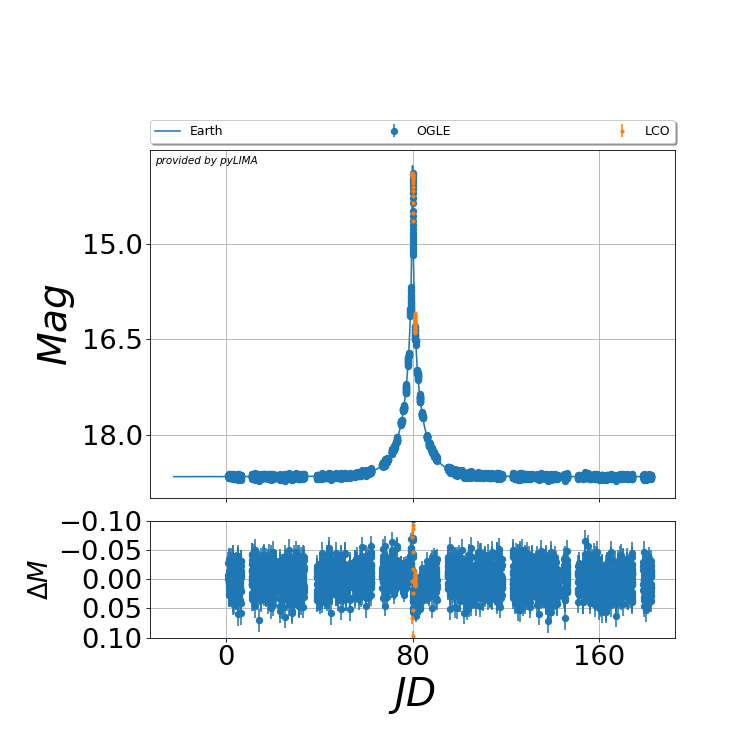

In [14]:
from pyLIMA.outputs import pyLIMA_plots
pyLIMA_plots.plot_lightcurves(pspl, my_fit.fit_results['best_model'])
plt.show()